# Housing price analysis

In this notebook, I analyze a housing dataset to understand what factors influence house prices using linear regression. For this project I used a dataset from Kaggle website and here is the link to exact dataset. https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data. I downloaded it from website and uploaded to my project.

My goal in this project is not just to build a model, but to interpret relationships between features such as:
- Living area (size of the house)
- Overall quality (material and finish quality)
- Garage capacity

Why I think this matters:
Understanding which features most affect price is useful for buyers, sellers, and real estate professionals when making pricing decisions.

So we have these questions to answer:
1. Does a larger house always cost more?
2. Does quality matter more than size?
3. What role does garage size play in pricing?

## Loading the dataset

We begin by loading the dataset into a pandas DataFrame.

This step is necessary to inspect the structure of the data and identify which variables are useful for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Understanding the dataset

Before performing any analysis, we need to explore the dataset structure.

So first we check:
- Number of rows and columns
- Data types
- Missing values

If data is missing or incorrectly formatted, it can distort analysis results. 

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Data cleaning and features selection

The original dataset contains many columns, but not all are relevant. So clean data ensures accurate statistical and regression results.

We select only:
- SalePrice (target variable, what we want to predict)
- GrLivArea (living area, size of house)
- OverallQual (quality rating)
- GarageCars (garage capacity)

We also remove missing values to ensure clean analysis.

In [3]:
df = df[['SalePrice', 'GrLivArea', 'OverallQual', 'GarageCars']]

df = df.dropna()

df.head()

,SalePrice,GrLivArea,OverallQual,GarageCars
0,208500,1710,7,2
1,181500,1262,6,2
2,223500,1786,7,2
3,140000,1717,7,3
4,250000,2198,8,3


## Exploratory analysis

We now look at simple summaries to understand how house prices vary across different features.
This helps us form expectations before building models. 

We expect that houses with higher quality ratings should have higher average prices.
If this pattern appears in the output, it confirms that quality is strongly related to price.

In [4]:
df.groupby('OverallQual')['SalePrice'].mean()

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

## Relationship between living area and price

We examine whether larger homes tend to have higher prices.

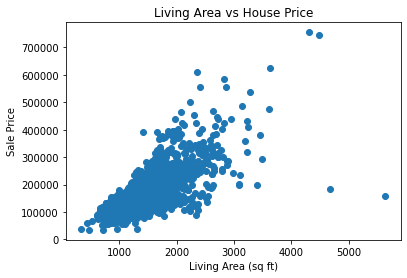

In [5]:
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.title('Living Area vs House Price')
plt.show()

There is a clear positive trend — as living area increases, house price also increases.

However, the points are spread out, which can mean that the size is not the only factor affecting price.

## Relationship between quality and price

Now we analyze how house quality affects price.

Quality includes materials, finishing, and construction standards.

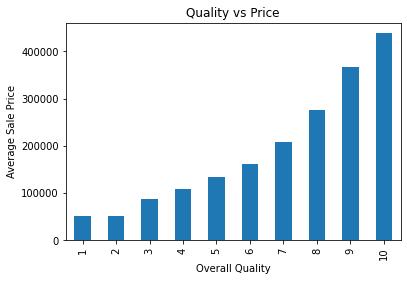

In [6]:
df.groupby('OverallQual')['SalePrice'].mean().plot(kind='bar')
plt.xlabel('Overall Quality')
plt.ylabel('Average Sale Price')
plt.title('Quality vs Price')
plt.show()

We can see that there is a strong upward trend.

Higher quality houses are significantly more expensive, showing that quality is one of the most important factors in pricing.

## Relationship between garage size and price

Now we check whether garage capacity affects house price. This is usually a secondary factor compared to size and quality.

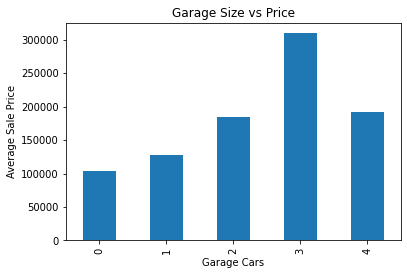

In [7]:
df.groupby('GarageCars')['SalePrice'].mean().plot(kind='bar')
plt.xlabel('Garage Cars')
plt.ylabel('Average Sale Price')
plt.title('Garage Size vs Price')
plt.show()

So what we see is that houses with larger garages tend to have higher prices, but the difference is not as strong as quality or size.

So garage size has a smaller influence on price.

## Linear regression: understanding the effect of living area

We use linear regression to measure how living area affects house price.

Instead of only observing trends in the plot, this method allows us to quantify the relationship.

Specifically, it shows how much the price is expected to change when the living area increases.

This helps us move from a visual observation to a numerical understanding of the relationship.

In [8]:
x = df['GrLivArea']
y = df['SalePrice']

slope, intercept = np.polyfit(x, y, 1)

y_pred = slope * x + intercept
print(y_pred)

0       201761.939688
1       153767.538871
2       209903.846969
3       202511.852201
4       254041.554863
            ...      
1455    195012.727073
1456    240650.259993
1457    269254.065837
1458    134055.552822
1459    153124.756718
Name: GrLivArea, Length: 1460, dtype: float64


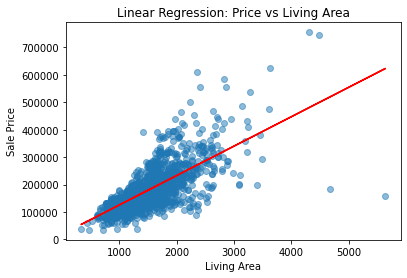

In [9]:
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_pred, color='red')
plt.xlabel('Living Area')
plt.ylabel('Sale Price')
plt.title('Linear Regression: Price vs Living Area')
plt.show()

The red line shows the general trend between size and price.

We can see that prices increase with size, but there is still a lot of variation. This means other factors also influence price.

## Multiple regression analysis

Now we use multiple variables together to better understand house prices.

We include Living area, Overall quality and Garage size.

This gives a more realistic model than using only one feature.


In [10]:
X = df[['GrLivArea', 'OverallQual', 'GarageCars']]
y = df['SalePrice']

X = X.copy()
X['Intercept'] = 1

coeffs = np.linalg.lstsq(X, y, rcond=None)[0]

coeffs

array([ 5.06742114e+01,  2.71048260e+04,  2.12989598e+04, -9.88324933e+04])

What the coefficients mean:

Each value tells how much the house price changes when that feature increases by 1 unit:

- Living area increases price slightly per square foot
- Overall quality has a large impact on price
- Garage size also increases price, but less than quality

So the key insight is that quality has the strongest influence on house price in this model.

# Conclusion

In this project, I studied what affects house prices using real housing data.

To analyze the relationships between features and price, I used **linear regression**. This method helps us go beyond simple observation and actually measure how much each factor influences the house price. For example, it shows how much the price changes when living area increases, or how much value is added by higher quality.

Main findings:

- **Living area** has a positive effect on price. Bigger houses usually cost more, but size alone does not explain everything. Even with a clear trend, there is still variation in prices, which means other factors also matter.

- **Overall quality** is the most important factor. Houses with higher quality are significantly more expensive, and the model shows this has the strongest impact compared to other variables.

- **Garage size** also increases price, but its effect is smaller compared to both quality and living area.

We can conclude that house prices are not determined by only one factor. It is a combination of size, quality, and features. Using linear regression helped us understand and quantify these relationships, showing which factors matter most instead of just looking at patterns visually. Overall, using multiple variables gives a much better understanding of real estate prices than using only one feature.